<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-4/ML_LAB_4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Classification on a Quadratic Dataset

## Aim

To generate a random dataset following a quadratic/nonlinear distribution and classify the generated data using Support Vector Machine (SVM).

## Problem Description

A linear classifier may not be able to correctly separate data when the classes have a nonlinear or quadratic relationship. This experiment aims to demonstrate how Support Vector Machine (SVM) with a nonlinear kernel can transform the feature space and learn a nonlinear decision boundary to effectively classify such a dataset.

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ============================================
# 2. GENERATE RANDOM QUADRATIC DATASET
# ============================================

np.random.seed(42)

n_samples_per_class = 100

X1_0 = np.random.uniform(-5, 5, n_samples_per_class)
X2_noise_0 = np.random.normal(0, 1.5, n_samples_per_class)
y_boundary_0 = X1_0**2
class_0_X2 = y_boundary_0 - np.random.uniform(2, 10, n_samples_per_class) + X2_noise_0
class_0_target = np.zeros(n_samples_per_class)

X1_1 = np.random.uniform(-5, 5, n_samples_per_class)
X2_noise_1 = np.random.normal(0, 1.5, n_samples_per_class)
y_boundary_1 = X1_1**2
class_1_X2 = y_boundary_1 + np.random.uniform(2, 10, n_samples_per_class) + X2_noise_1
class_1_target = np.ones(n_samples_per_class)

df_class_0 = pd.DataFrame({'Feature 1': X1_0, 'Feature 2': class_0_X2, 'Target': class_0_target})
df_class_1 = pd.DataFrame({'Feature 1': X1_1, 'Feature 2': class_1_X2, 'Target': class_1_target})

df = pd.concat([df_class_0, df_class_1], ignore_index=True)

X = df[['Feature 1', 'Feature 2']]
y = df['Target']

In [3]:
# ============================================
# 3. DISPLAY DATASET
# ============================================

display(df.head())

,Feature 1,Feature 2,Target
0,-1.254599,-6.653902,0.0
1,4.507143,13.844731,0.0
2,2.319939,-1.095471,0.0
3,0.986585,-7.948145,0.0
4,-3.439814,7.940866,0.0


In [4]:
# ============================================
# 4. CHECK DATASET DIMENSIONS
# ============================================

print(f"Dataset shape: {df.shape}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Dataset shape: (200, 3)
Features shape: (200, 2)
Target shape: (200,)


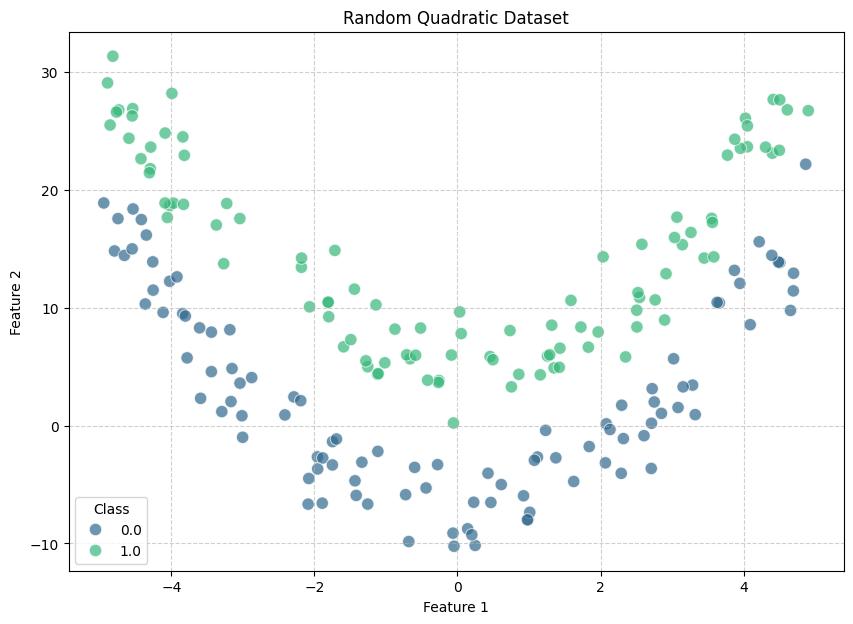

In [5]:
# ============================================
# 5. VISUALIZE THE GENERATED DATA
# ============================================

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Feature 1', y='Feature 2', hue='Target', data=df, palette='viridis', s=80, marker='o', alpha=0.7)
plt.title('Random Quadratic Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Class')
plt.show()

In [6]:
# ============================================
# 6. SPLIT DATASET INTO TRAINING AND TESTING SETS
# ============================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (160, 2)
Testing set shape: (40, 2)


In [7]:
# ============================================
# 7. FEATURE SCALING
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


In [8]:
# ============================================
# 8. CREATE SVM MODEL
# ============================================

svm_model = SVC(kernel='rbf', probability=True, random_state=42)

print("SVM model with RBF kernel created.")

SVM model with RBF kernel created.


In [9]:
# ============================================
# 9. TRAIN SVM MODEL
# ============================================

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [10]:
# ============================================
# 10. MAKE PREDICTIONS
# ============================================

y_pred = svm_model.predict(X_test_scaled)

comparison_df = pd.DataFrame({'Actual Class': y_test, 'Predicted Class': y_pred})
display(comparison_df.head())

,Actual Class,Predicted Class
37,0.0,0.0
140,1.0,1.0
195,1.0,1.0
196,1.0,1.0
23,0.0,0.0


In [11]:
# ============================================
# 11. MODEL ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9750


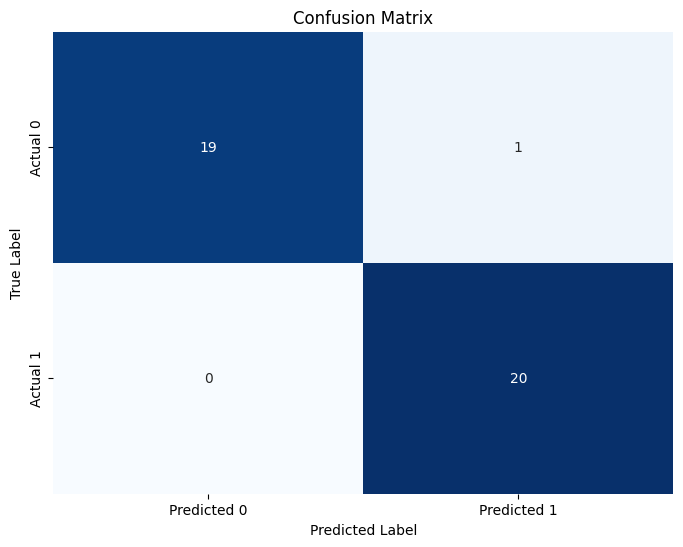

In [12]:
# ============================================
# 12. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [13]:
# ============================================
# 13. CLASSIFICATION REPORT
# ============================================

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97        20
         1.0       0.95      1.00      0.98        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



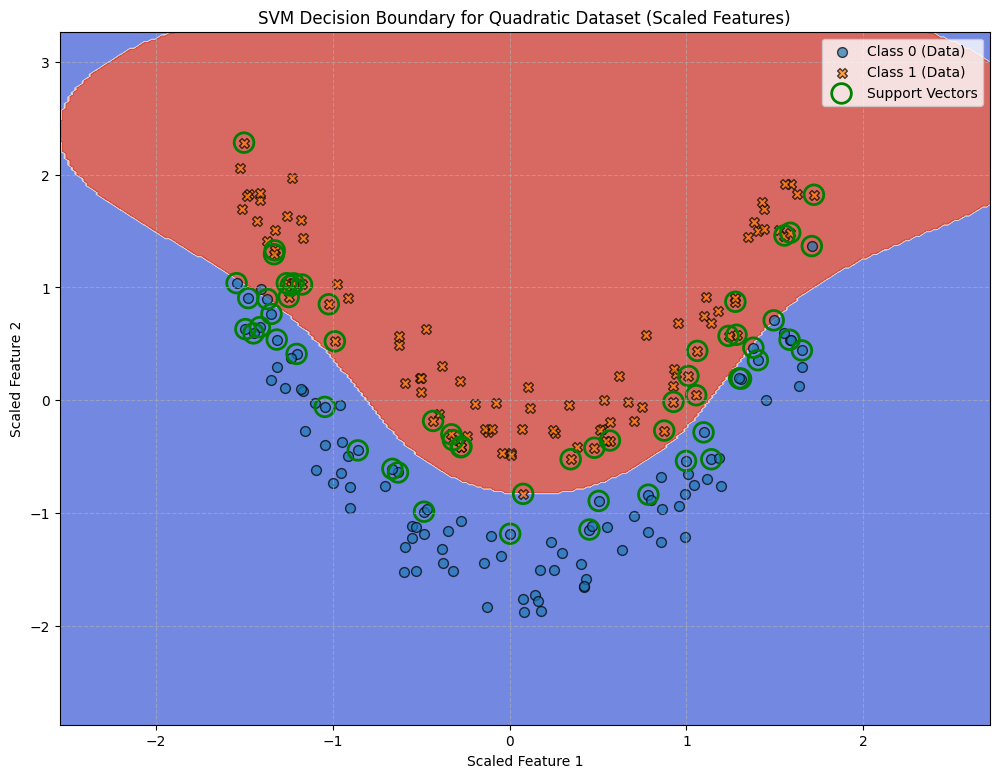

In [14]:
# ============================================
# 14. VISUALIZE SVM DECISION BOUNDARY
# ============================================

def plot_decision_boundary(X_train_scaled, y_train, X_test_scaled, y_test, model, scaler):
    X_combined_scaled = np.vstack((X_train_scaled, X_test_scaled))
    y_combined = np.hstack((y_train, y_test))

    x_min, x_max = X_combined_scaled[:, 0].min() - 1, X_combined_scaled[:, 0].max() + 1
    y_min, y_max = X_combined_scaled[:, 1].min() - 1, X_combined_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(12, 9))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
    plt.scatter(X_combined_scaled[y_combined == 0, 0], X_combined_scaled[y_combined == 0, 1], label='Class 0 (Data)', marker='o', s=50, alpha=0.7, edgecolors='k')
    plt.scatter(X_combined_scaled[y_combined == 1, 0], X_combined_scaled[y_combined == 1, 1], label='Class 1 (Data)', marker='X', s=50, alpha=0.7, edgecolors='k')

    # Plot support vectors (transformed back to original scale for plotting with original points)
    # Note: Support vectors are in the scaled space, so we plot them directly on the scaled grid.
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=200, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors')

    plt.title('SVM Decision Boundary for Quadratic Dataset (Scaled Features)')
    plt.xlabel('Scaled Feature 1')
    plt.ylabel('Scaled Feature 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_decision_boundary(X_train_scaled, y_train, X_test_scaled, y_test, svm_model, scaler)

## Display Support Vectors

Support vectors are the data points closest to the decision boundary. They are the most influential points in defining the optimal hyperplane and are crucial for the SVM algorithm. These are often the 'hardest' to classify points. In the plot above, they are highlighted with green circles.

In [15]:
# ============================================
# 15. DISPLAY SUPPORT VECTORS
# ============================================

print("Number of support vectors for each class:", svm_model.n_support_)
print("Support vectors (scaled):")
print(svm_model.support_vectors_[:5]) # Display first 5 for brevity

Number of support vectors for each class: [29 30]
Support vectors (scaled):
[[ 1.14073521 -0.52209337]
 [ 1.30886533  0.19139087]
 [-0.85874414 -0.4435503 ]
 [-0.63133574 -0.63942151]
 [-1.20501053  0.41099254]]


In [16]:
# ============================================
# 16. TEST A NEW DATA POINT
# ============================================

# Generate a new random data point
new_point = np.array([[np.random.uniform(-5, 5), np.random.uniform(-10, 20)]])

# Scale the new data point using the previously fitted scaler
new_point_scaled = scaler.transform(new_point)

# Predict the class of the new data point
predicted_class = svm_model.predict(new_point_scaled)

print(f"New Data Point (Original): {new_point[0]}")
print(f"New Data Point (Scaled): {new_point_scaled[0]}")
print(f"Predicted Class for new data point: {int(predicted_class[0])}")

New Data Point (Original): [-0.89603173 19.47135851]
New Data Point (Scaled): [-0.20214049  1.0943524 ]
Predicted Class for new data point: 1


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [17]:
# ============================================
# 17. FINAL RESULTS
# ============================================

final_accuracy_percentage = accuracy * 100

print("Model: Support Vector Machine")
print("Kernel: RBF")
print(f"Accuracy: {final_accuracy_percentage:.2f}%")

Model: Support Vector Machine
Kernel: RBF
Accuracy: 97.50%


## Observation

The generated data clearly exhibits a nonlinear/quadratic distribution, making it challenging for simple linear classifiers. A straight-line classifier would be fundamentally unsuitable for accurately separating these two classes due to their curved relationship. The RBF-kernel SVM, however, successfully learned a nonlinear decision boundary, as evidenced by the decision boundary plot. The support vectors, which are the training points closest to this boundary, played a critical role in influencing the position and shape of the separating boundary, demonstrating their importance in SVM's learning process. The decision-boundary graph vividly illustrates how the RBF-kernel SVM effectively separates the two classes by transforming the feature space.

## Conclusion

A random quadratic dataset was successfully generated and classified using a Support Vector Machine. The nonlinear RBF kernel proved effective in modeling the inherent curved relationship between the features and their respective classes. The model's performance was evaluated comprehensively through accuracy, a confusion matrix, and a classification report, all indicating a successful classification of the non-linear data.